# 05. Incertidumbre de estimación

En el notebook 04 vimos que los pesos óptimos cambian mucho según el periodo usado para estimar. Aquí cuantifico por qué:

1. **Error de estimación de las medias:** cuánto se equivoca, como mínimo, una rentabilidad media estimada con 10 años de datos.
2. **Bootstrap de los pesos:** remuestreo los datos muchas veces y miro cuánto cambia la cartera de máximo Sharpe.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.portfolio import (error_estandar_medias, error_estandar_sharpe,
                               bootstrap_pesos_max_sharpe, resumen_pesos, medias_shrinkage)

precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)
rentabilidades = precios.pct_change().dropna()
rf_hist = pd.read_csv("../data/rf_hist.csv", index_col=0).squeeze("columns")["rf_hist"]

### Error de estimación de la rentabilidad media

Una rentabilidad media estimada con pocos años de datos es muy imprecisa. El error estándar de la media es aproximadamente la volatilidad anual dividida por la raíz de los años de datos. El intervalo del 95 % es la media ± 2 errores estándar.

In [2]:
print(f"Error estándar aproximado del Sharpe de cada activo: {error_estandar_sharpe(rentabilidades):.2f}")
error_estandar_medias(rentabilidades).round(3)

Error estándar aproximado del Sharpe de cada activo: 0.32


,Rentabilidad anual,Volatilidad anual,Error estándar,IC 95% inferior,IC 95% superior
AGG,0.021,0.054,0.017,-0.013,0.055
EEM,0.099,0.203,0.064,-0.030,0.228
EFA,0.096,0.172,0.055,-0.013,0.205
GLD,0.146,0.148,0.047,0.052,0.240
SPY,0.155,0.180,0.057,0.041,0.269
VNQ,0.073,0.208,0.066,-0.058,0.205


Solo GLD y SPY tienen un intervalo que no incluye el 0. Además, los intervalos de todos los activos se solapan mucho: con estos datos no se puede afirmar que GLD o SPY rindan de verdad más que EEM o EFA. El error estándar del Sharpe (≈ 0,32) también es grande.

Bootstrap de los pesos óptimos

Remuestreo los datos 200 veces, pegando bloques de 21 días (1 mes) elegidos al azar (así se conserva la dependencia entre días consecutivos) hasta llegar a una muestra de 10 años, y en cada remuestreo recalculo la cartera de máximo Sharpe. Si los pesos cambian mucho de un remuestreo a otro, la "cartera óptima" es en realidad un rango.

Este bootstrap solo mide el **error de muestreo**: remuestrea los mismos diez años. No captura un cambio de régimen como el de los tipos de interés.

In [3]:
pesos_boot = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=200, z=1.0)
resumen_pesos(pesos_boot).round(3)

,Peso medio,Percentil 5,Percentil 95
AGG,0.018,0.000,0.165
EEM,0.003,0.000,0.000
EFA,0.001,0.000,0.000
GLD,0.549,0.303,0.796
SPY,0.425,0.197,0.669
VNQ,0.004,0.000,0.000


- GLD y SPY concentran casi toda la cartera, pero con rangos muy anchos: GLD entre 0,30 y 0,80 y SPY entre 0,20 y 0,67.
- EEM, EFA y VNQ tienen el percentil 95 en 0: en más del 95 % de los remuestreos su peso es exactamente 0.
- AGG vale 0 en la gran mayoría de los remuestreos y entra pocas veces con pesos altos (su percentil 95 es 0,165), por eso su media es pequeña pero no nula.

### Distribución de los pesos (KDE) y Box-Plot

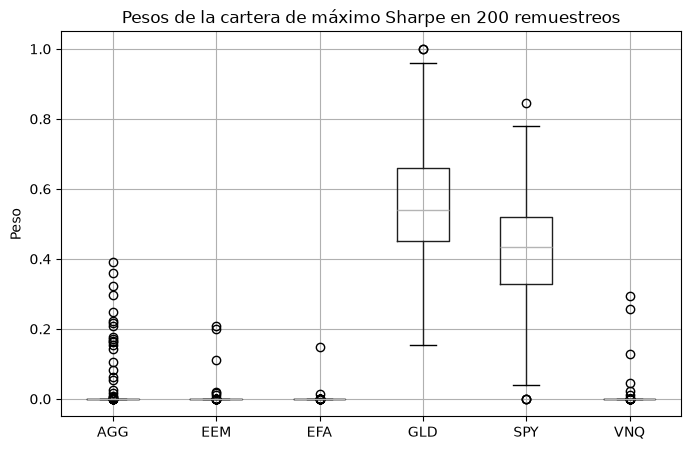

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
pesos_boot.boxplot(ax=ax)
ax.set_title("Pesos de la cartera de máximo Sharpe en 200 remuestreos")
ax.set_ylabel("Peso")
plt.show()

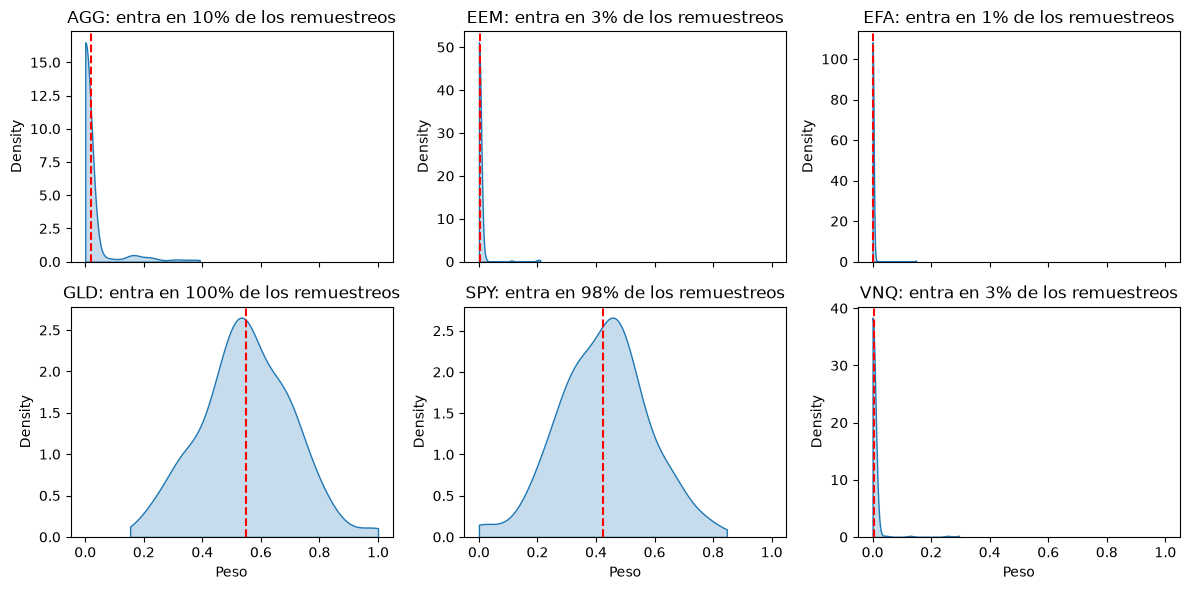

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for ax, activo in zip(axes.ravel(), pesos_boot.columns):
    sns.kdeplot(pesos_boot[activo], ax=ax, fill=True, cut=0)
    ax.axvline(pesos_boot[activo].mean(), color="red", linestyle="--")
    veces = (pesos_boot[activo] > 0.01).mean()
    ax.set_title(f"{activo}: entra en {veces:.0%} de los remuestreos")
    ax.set_xlabel("Peso")
plt.tight_layout()

Cada curva muestra cómo se reparten los 200 pesos de un activo. Un pico alto y estrecho significa que el peso casi siempre es el mismo; una curva ancha, que los remuestreos no se ponen de acuerdo. La línea roja es el peso medio y el título indica en qué porcentaje de los remuestreos el activo recibe algún peso.

AGG, EEM, EFA y VNQ tienen un pico en 0: casi nunca entran. GLD y SPY tienen curvas anchas: su peso depende mucho de la muestra.

<Axes: xlabel='GLD', ylabel='SPY'>

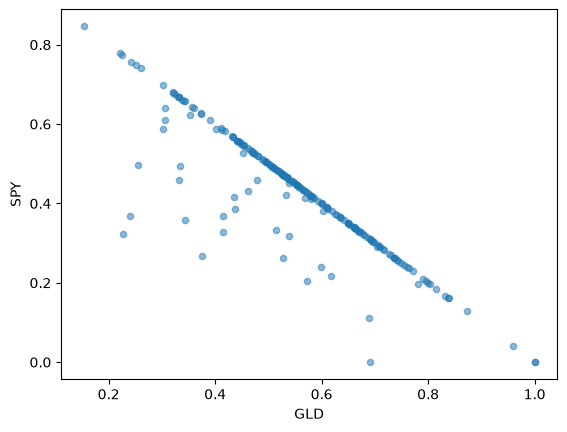

In [6]:
pesos_boot.plot.scatter(x="GLD", y="SPY", alpha=0.5)

Cada punto es un remuestreo. Los puntos sobre la diagonal son carteras formadas solo por GLD y SPY (la suma de pesos es 1). El optimizador siempre elige entre oro y bolsa, pero la proporción es inestable.

### Shrinkage de las rentabilidades medias

Las medias históricas son muy imprecisas con solo diez años de datos, y el optimizador las toma al pie de la letra. Para suavizarlas, mezclo la media de cada activo con un valor de referencia (el prior): la rentabilidad que tendría si todos los activos ofrecieran el mismo Sharpe, igual a la media de los Sharpe de los seis.

prior = rf + Sharpe medio × volatilidad del activo

media ajustada = Z · media del activo + (1 − Z) · prior

Equivale a encoger el Sharpe de cada activo hacia el Sharpe medio. Z es la credibilidad que doy a los datos: Z = 1 usa solo la media histórica y Z = 0 usa solo el prior.

In [7]:
medias_orig = rentabilidades.mean() * 252
medias_aj = medias_shrinkage(rentabilidades, z=0.5, rf=rf_hist)
pd.DataFrame({"Media original": medias_orig, "Media ajustada": medias_aj}).round(3)

,Media original,Media ajustada
AGG,0.021,0.033
EEM,0.099,0.105
EFA,0.096,0.096
GLD,0.146,0.116
SPY,0.155,0.128
VNQ,0.073,0.093


Las medias de GLD y SPY bajan (GLD de 0,146 a 0,116; SPY de 0,155 a 0,128) y las de AGG, EEM y VNQ suben (AGG de 0,021 a 0,033; VNQ de 0,073 a 0,093). EFA casi no cambia. Las diferencias entre activos se reducen, pero GLD y SPY siguen siendo los de mayor rentabilidad esperada.

### Bootstrap con shrinkage (Z = 0,5)

Repito el bootstrap con las medias ajustadas al 50 % hacia el prior. Comparo con el caso sin ajuste (Z = 1) el peso medio y el ancho del intervalo entre los percentiles 5 y 95, que mide la estabilidad de cada peso: cuanto menor, más estable.

In [8]:
pesos_z05 = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=200, z=0.5)

comparacion = pd.DataFrame({
    "Peso medio (Z=1)": pesos_boot.mean(),
    "Peso medio (Z=0,5)": pesos_z05.mean(),
    "Ancho P5-P95 (Z=1)": pesos_boot.quantile(0.95) - pesos_boot.quantile(0.05),
    "Ancho P5-P95 (Z=0,5)": pesos_z05.quantile(0.95) - pesos_z05.quantile(0.05),
})
comparacion.round(3)

,Peso medio (Z=1),"Peso medio (Z=0,5)",Ancho P5-P95 (Z=1),"Ancho P5-P95 (Z=0,5)"
AGG,0.018,0.087,0.165,0.387
EEM,0.003,0.004,0.000,0.027
EFA,0.001,0.001,0.000,0.000
GLD,0.549,0.510,0.493,0.459
SPY,0.425,0.393,0.472,0.364
VNQ,0.004,0.005,0.000,0.016


Con Z = 0,5, el ancho P5-P95 de SPY baja un 23 % (de 0,472 a 0,364) y el de GLD solo un 7 % (de 0,493 a 0,459). El peso medio de AGG sube de 0,018 a 0,087, y su ancho también aumenta (de 0,165 a 0,387): ahora entra en más remuestreos, lo que no indica menos estabilidad. GLD y SPY siguen sumando el 90 % de la cartera.

### Barrido de Z

Repito el bootstrap con Z = 0, 0,25, 0,5, 0,75 y 1 para ver cómo cambian los pesos medios y su dispersión al dar más o menos credibilidad a los datos.

,AGG,EEM,EFA,GLD,SPY,VNQ
Z,,,,,,
0.00,0.520,0.065,0.022,0.211,0.141,0.041
0.25,0.235,0.009,0.001,0.416,0.333,0.006
0.50,0.087,0.004,0.001,0.510,0.393,0.005
0.75,0.036,0.003,0.001,0.540,0.415,0.004
1.00,0.018,0.003,0.001,0.549,0.425,0.004


,AGG,EEM,EFA,GLD,SPY,VNQ
Z,,,,,,
0.00,0.070,0.050,0.026,0.061,0.056,0.047
0.25,0.473,0.048,0.000,0.424,0.282,0.043
0.50,0.387,0.027,0.000,0.459,0.364,0.016
0.75,0.277,0.004,0.000,0.481,0.428,0.000
1.00,0.165,0.000,0.000,0.493,0.472,0.000


<Axes: title={'center': 'Peso medio de cada activo según Z'}, xlabel='Z'>

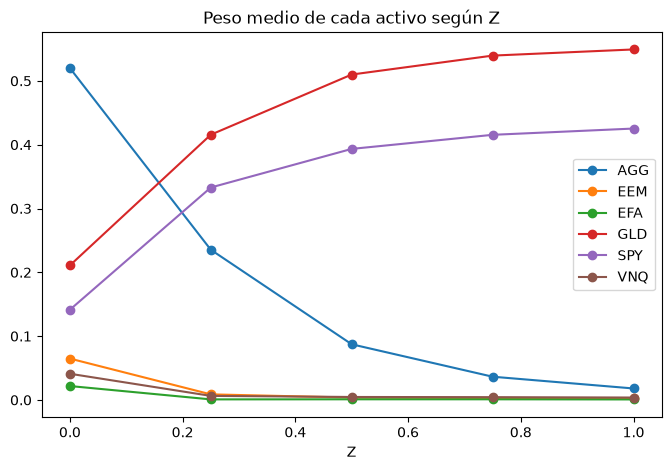

In [9]:
zs = [0, 0.25, 0.5, 0.75, 1]
resultados = {z: bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=200, z=z) for z in zs}

medios = pd.DataFrame({z: p.mean() for z, p in resultados.items()}).T
anchos = pd.DataFrame({z: p.quantile(0.95) - p.quantile(0.05) for z, p in resultados.items()}).T
medios.index.name = anchos.index.name = "Z"

display(medios.round(3))
display(anchos.round(3))
medios.plot(marker="o", figsize=(8, 5), title="Peso medio de cada activo según Z")

### Resultado del barrido de Z

Con Z = 0 la cartera se apoya en AGG (52 %), el activo más tranquilo y el que más diversifica; GLD y SPY suman solo un 35 %. Los pesos son muy estables (ancho P5-P95 entre 0,03 y 0,07) porque no dependen de las medias de los datos, solo de la covarianza.

Al subir Z, AGG cede su peso a GLD y SPY, que ya suman el 75 % con Z = 0,25 y el 97 % con Z = 1. La mayor incertidumbre está en Z = 0,25 (el ancho de AGG llega a 0,47): el optimizador duda entre una cartera diversificada y una de oro y bolsa.

Un peso estable no implica una cartera mejor, y el prior de igual Sharpe es una suposición fuerte. Para elegir Z hace falta evaluar las carteras fuera de la muestra.